In [ ]:
!pip install scikit-fuzzy -q
!sudo apt-get install swi-prolog -y -q
!pip install pyswip -q

Reading package lists...
Building dependency tree...
Reading state information...
swi-prolog is already the newest version (8.4.2+dfsg-2ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [ ]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import warnings
warnings.filterwarnings('ignore')

# Style chung cho biểu đồ
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

LABEL_NAMES = ['Normal', 'Mild', 'Moderate', 'Severe', 'Extremely Severe']
COLORS_5    = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#8e44ad']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Kỳ 6/Hệ Chuyên gia/data/data.csv'
df_raw = pd.read_csv(file_path, sep=None, engine='python', on_bad_lines='warn')

print(f"📐 Shape gốc: {df_raw.shape}")
print(f"📋 Tổng số cột: {df_raw.columns.tolist()[:25]}")
df_raw.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📐 Shape gốc: (39775, 172)
📋 Tổng số cột: ['Q1A', 'Q1I', 'Q1E', 'Q2A', 'Q2I', 'Q2E', 'Q3A', 'Q3I', 'Q3E', 'Q4A', 'Q4I', 'Q4E', 'Q5A', 'Q5I', 'Q5E', 'Q6A', 'Q6I', 'Q6E', 'Q7A', 'Q7I', 'Q7E', 'Q8A', 'Q8I', 'Q8E', 'Q9A']


,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,...,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,...,2,1,1,4,3,60,1,1,3,NaN


**Tên đề tài:** Hệ chuyên gia đánh giá sức khỏe tâm thần dựa trên thang đo DASS-42 và Logic Mờ

**Kiến trúc hệ thống:**
[Dữ liệu DASS-42] → [**Phase 1:** EDA & Tiền xử lý] → [**Phase 2**: Decision Tree → Trích xuất luật sàng lọc] → [**Phase 3**: Prolog Knowledge Base — Suy diễn tiến/lùi] → [**Phase 4**: Fuzzy Logic Engine — Xử lý tri thức không chắc chắn] → [**Phase 5**: Tích hợp & Demo hệ chuyên gia hoàn chỉnh]

**Thang đo DASS-42**
- **42 câu hỏi**, mỗi câu trả lời từ 0–3
- Chia 3 nhóm: Depression (14 câu), Anxiety (14 câu), Stress (14 câu)
- Điểm mỗi nhóm: 0–42, phân loại 5 mức: Normal → Extremely Severe

**1. Phase 1: EDA & Tiền xử lý**

In [ ]:
q_cols    = [f'Q{i}A' for i in range(1, 43)]
available = [c for c in q_cols if c in df_raw.columns]
print(f"- Có {len(available)}/42 cột câu hỏi")

df = df_raw[available].copy()
df = df - 1  # Chuyển thang 1-4 → 0-3

# Loại dòng ngoài [0,3]
mask = ((df >= 0) & (df <= 3)).all(axis=1)
df   = df[mask].reset_index(drop=True)
print(f"- Sau làm sạch: {len(df)} mẫu hợp lệ")

# Mapping câu hỏi theo chuẩn DASS-42
DEPRESSION_Qs = [3,5,10,13,16,17,21,24,26,31,34,37,38,42]
ANXIETY_Qs    = [2,4,7,9,15,19,20,23,25,28,30,36,40,41]
STRESS_Qs     = [1,6,8,11,12,14,18,22,27,29,32,33,35,39]

def get_cols(q_list):
    return [f'Q{i}A' for i in q_list]

df['D_score'] = df[get_cols(DEPRESSION_Qs)].sum(axis=1)
df['A_score'] = df[get_cols(ANXIETY_Qs)].sum(axis=1)
df['S_score'] = df[get_cols(STRESS_Qs)].sum(axis=1)

print("- Thống kê điểm 3 chiều:")
print(df[['D_score','A_score','S_score']].describe().round(2))

- Có 42/42 cột câu hỏi
- Sau làm sạch: 39775 mẫu hợp lệ
- Thống kê điểm 3 chiều:
        D_score   A_score   S_score
count  39775.00  39775.00  39775.00
mean      21.06     16.05     21.15
std       12.32     10.25     10.52
min        0.00      0.00      0.00
25%       11.00      8.00     13.00
50%       21.00     15.00     21.00
75%       32.00     23.00     29.00
max       42.00     42.00     42.00


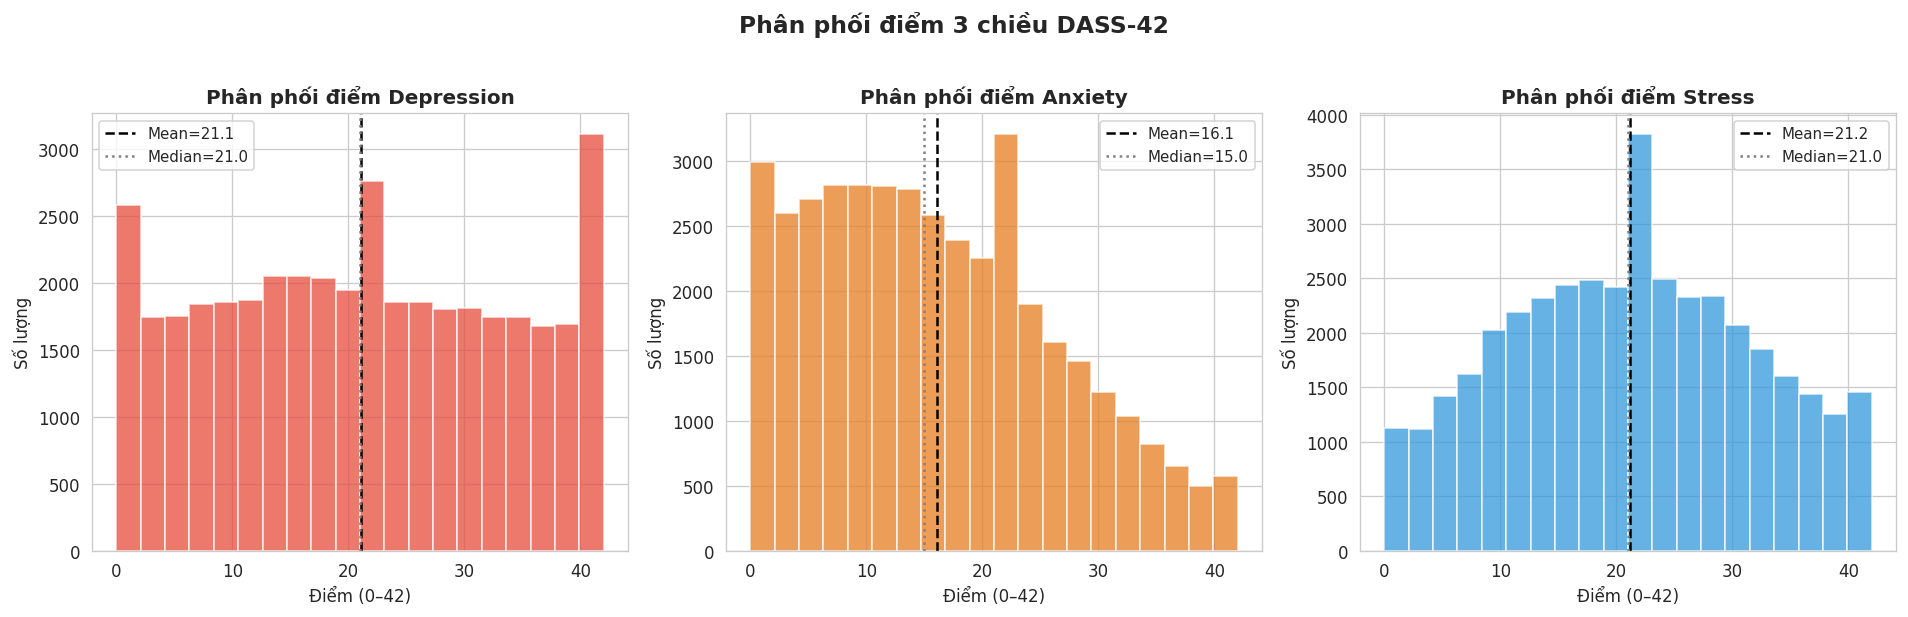

In [ ]:
# @title
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label, color in zip(
    axes,
    ['D_score', 'A_score', 'S_score'],
    ['Depression', 'Anxiety', 'Stress'],
    ['#e74c3c', '#e67e22', '#3498db']
):
    ax.hist(df[col], bins=20, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='gray', linestyle=':', linewidth=1.5,
               label=f'Median={df[col].median():.1f}')
    ax.set_title(f'Phân phối điểm {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Điểm (0–42)')
    ax.set_ylabel('Số lượng')
    ax.legend(fontsize=9)

plt.suptitle('Phân phối điểm 3 chiều DASS-42', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

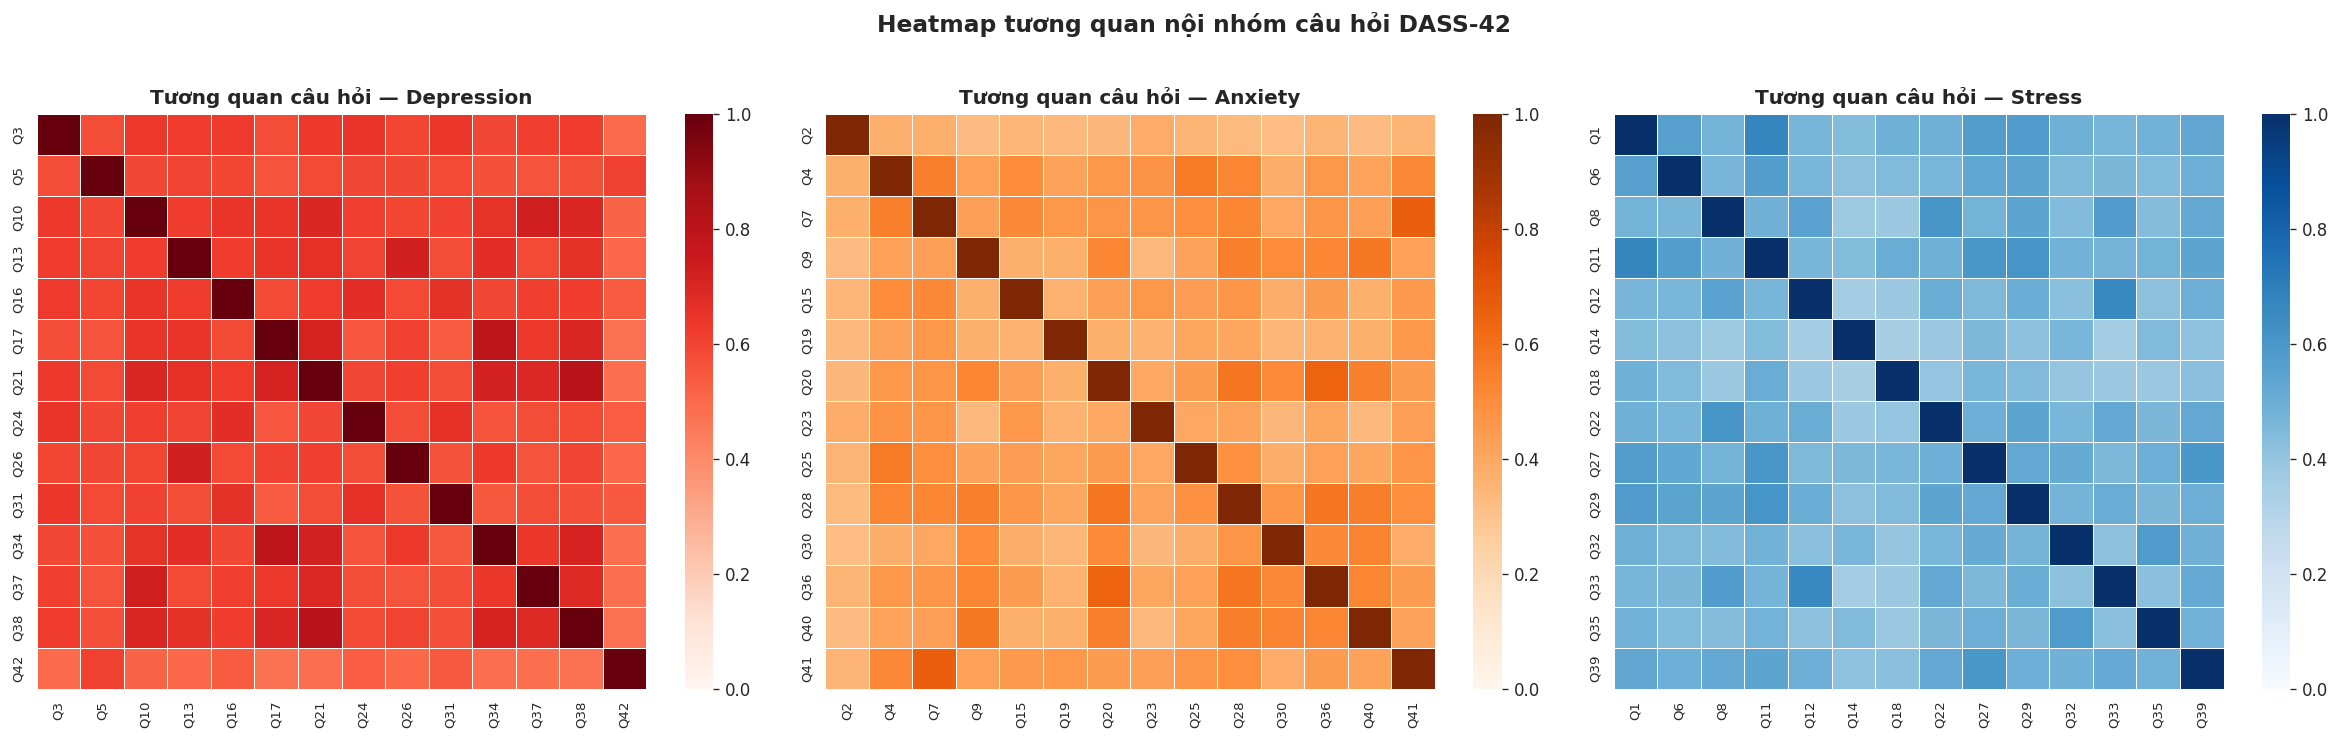


Tương quan giữa D_score, A_score, S_score:
         D_score  A_score  S_score
D_score     1.00    0.670    0.740
A_score     0.67    1.000    0.802
S_score     0.74    0.802    1.000


In [ ]:
# @title
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

groups = [
    (DEPRESSION_Qs, 'Depression', 'Reds'),
    (ANXIETY_Qs,    'Anxiety',    'Oranges'),
    (STRESS_Qs,     'Stress',     'Blues'),
]

for ax, (q_list, title, cmap) in zip(axes, groups):
    corr = df[get_cols(q_list)].corr()
    sns.heatmap(corr, ax=ax, cmap=cmap, vmin=0, vmax=1,
                annot=False, linewidths=0.3,
                xticklabels=[f'Q{q}' for q in q_list],
                yticklabels=[f'Q{q}' for q in q_list])
    ax.set_title(f'Tương quan câu hỏi — {title}', fontweight='bold')
    ax.tick_params(axis='both', labelsize=8)

plt.suptitle('Heatmap tương quan nội nhóm câu hỏi DASS-42',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tương quan giữa 3 điểm tổng
print("\nTương quan giữa D_score, A_score, S_score:")
print(df[['D_score','A_score','S_score']].corr().round(3))

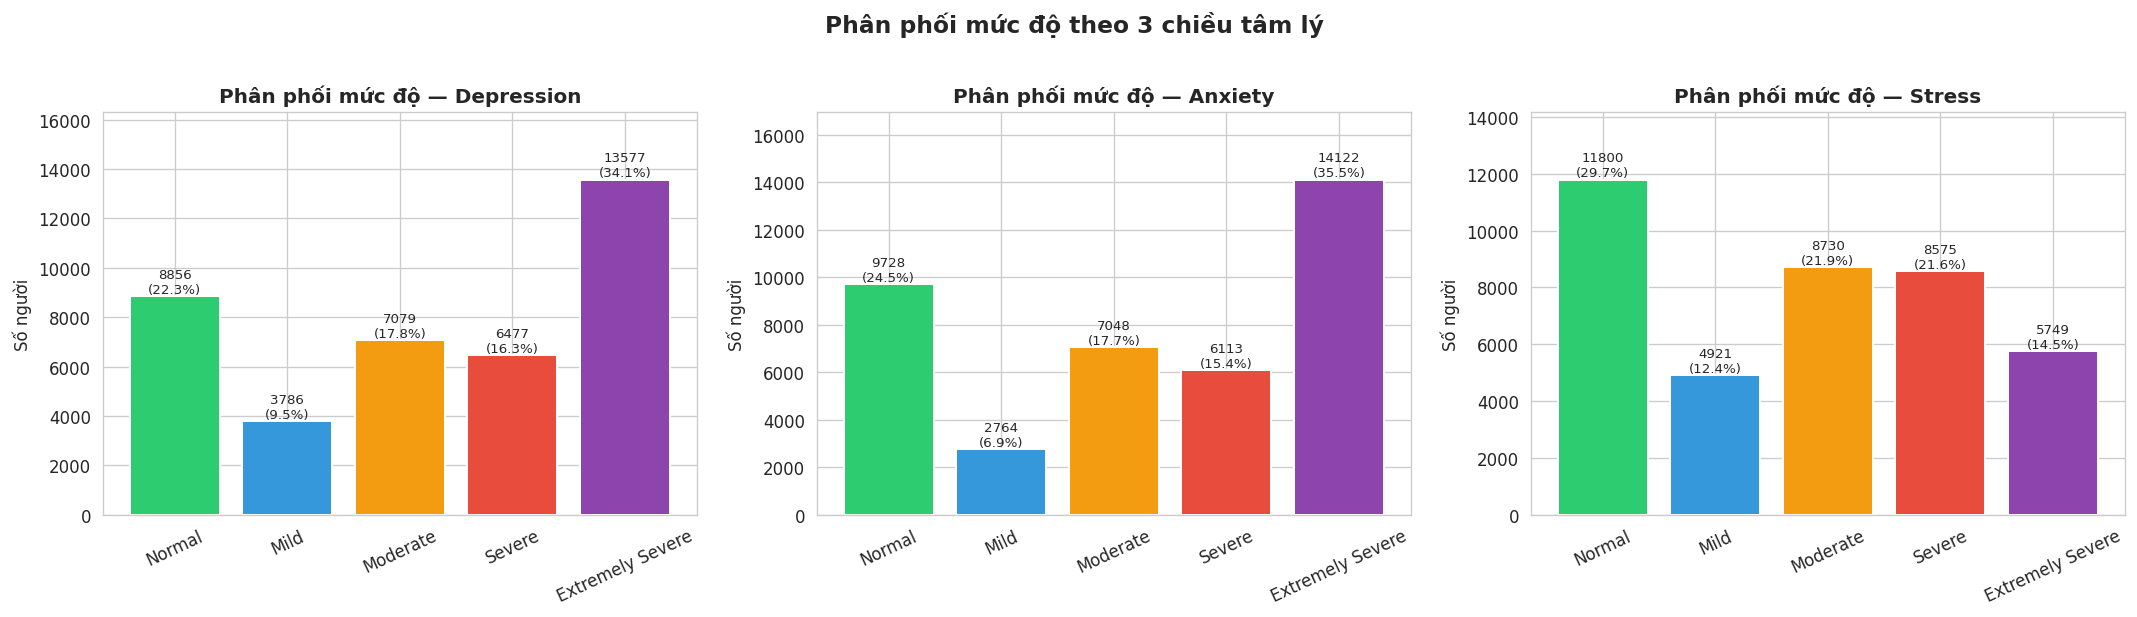

In [ ]:
def label_depression(s):
    if s<=9: return 0
    elif s<=13: return 1
    elif s<=20: return 2
    elif s<=27: return 3
    else: return 4

def label_anxiety(s):
    if s<=7: return 0
    elif s<=9: return 1
    elif s<=14: return 2
    elif s<=19: return 3
    else: return 4

def label_stress(s):
    if s<=14: return 0
    elif s<=18: return 1
    elif s<=25: return 2
    elif s<=33: return 3
    else: return 4

df['D_label'] = df['D_score'].apply(label_depression)
df['A_label'] = df['A_score'].apply(label_anxiety)
df['S_label'] = df['S_score'].apply(label_stress)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, title, color_list) in zip(axes, [
    ('D_label', 'Depression', COLORS_5),
    ('A_label', 'Anxiety',    COLORS_5),
    ('S_label', 'Stress',     COLORS_5),
]):
    counts = df[col].value_counts().sort_index()
    bars   = ax.bar([LABEL_NAMES[i] for i in counts.index],
                    counts.values,
                    color=[color_list[i] for i in counts.index],
                    edgecolor='white', linewidth=1.2)
    # Thêm số lượng lên đầu mỗi cột
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Phân phối mức độ — {title}', fontweight='bold')
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylabel('Số người')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Phân phối mức độ theo 3 chiều tâm lý', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**2. Phase 2: Decision Tree - Trích xuất luật sàng lọc**

In [ ]:
results = {}

for group, q_list, label_col in [
    ('Depression', DEPRESSION_Qs, 'D_label'),
    ('Anxiety',    ANXIETY_Qs,    'A_label'),
    ('Stress',     STRESS_Qs,     'S_label'),
]:
    X = df[get_cols(q_list)]
    y = df[label_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    param_grid = {'max_depth': [3,4,5,6,7,8]}
    grid = GridSearchCV(
        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)
    clf = grid.best_estimator_

    # Cross-validation score
    cv_scores = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')

    acc       = clf.score(X_test, y_test)
    threshold = round(clf.tree_.threshold[0], 1)

    importances = pd.Series(clf.feature_importances_, index=get_cols(q_list))
    top2        = importances.nlargest(2)

    results[group] = {
        'clf': clf, 'feature_names': get_cols(q_list),
        'q_list': q_list, 'accuracy': acc,
        'threshold': threshold, 'top2': top2,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'X_test': X_test, 'y_test': y_test,
    }

    print(f"{'='*55}")
    print(f"[{group}]  Best depth: {grid.best_params_['max_depth']}")
    print(f"  Test Accuracy : {acc:.3f}")
    print(f"  CV F1 (macro) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  Top-2 screening questions:")
    for feat, imp in top2.items():
        print(f"    {feat}  importance={imp:.4f}")
    print(f"\n{classification_report(y_test, clf.predict(X_test), target_names=LABEL_NAMES, zero_division=0)}")

[Depression]  Best depth: 8
  Test Accuracy : 0.751
  CV F1 (macro) : 0.703 ± 0.010
  Top-2 screening questions:
    Q21A  importance=0.2322
    Q10A  importance=0.2144

                  precision    recall  f1-score   support

          Normal       0.93      0.78      0.85      1771
            Mild       0.43      0.63      0.51       757
        Moderate       0.67      0.63      0.65      1416
          Severe       0.57      0.73      0.64      1295
Extremely Severe       0.96      0.84      0.89      2716

        accuracy                           0.75      7955
       macro avg       0.71      0.72      0.71      7955
    weighted avg       0.79      0.75      0.76      7955

[Anxiety]  Best depth: 8
  Test Accuracy : 0.676
  CV F1 (macro) : 0.597 ± 0.008
  Top-2 screening questions:
    Q28A  importance=0.2095
    Q7A  importance=0.1489

                  precision    recall  f1-score   support

          Normal       0.88      0.79      0.83      1946
            Mild      

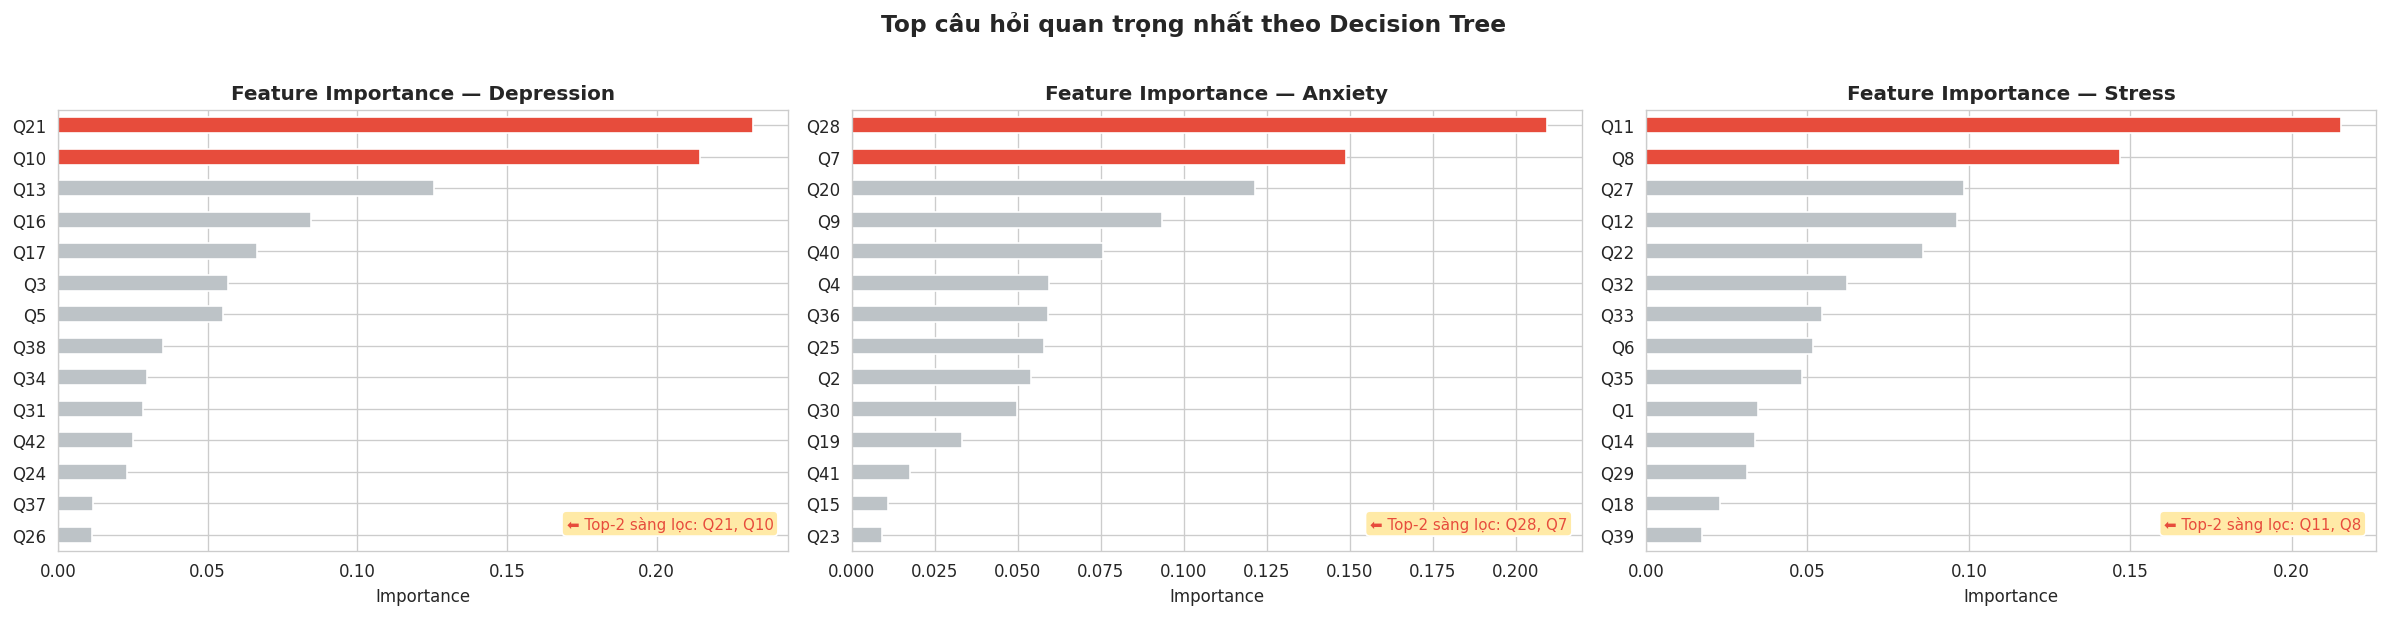

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (group, res) in zip(axes, results.items()):
    imp = pd.Series(res['clf'].feature_importances_,
                    index=[f"Q{q}" for q in res['q_list']]
                    ).sort_values(ascending=True)

    colors = ['#e74c3c' if i >= len(imp)-2 else '#bdc3c7'
              for i in range(len(imp))]
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {group}', fontweight='bold')
    ax.set_xlabel('Importance')

    # Đánh dấu top-2
    top2_names = [f"Q{q}" for q in [int(f.replace('Q','').replace('A',''))
                                     for f in res['top2'].index]]
    ax.annotate(f"⬅ Top-2 sàng lọc: {', '.join(top2_names)}",
                xy=(0.98, 0.05), xycoords='axes fraction',
                ha='right', fontsize=9, color='#e74c3c',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeaa7'))

plt.suptitle('Top câu hỏi quan trọng nhất theo Decision Tree',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

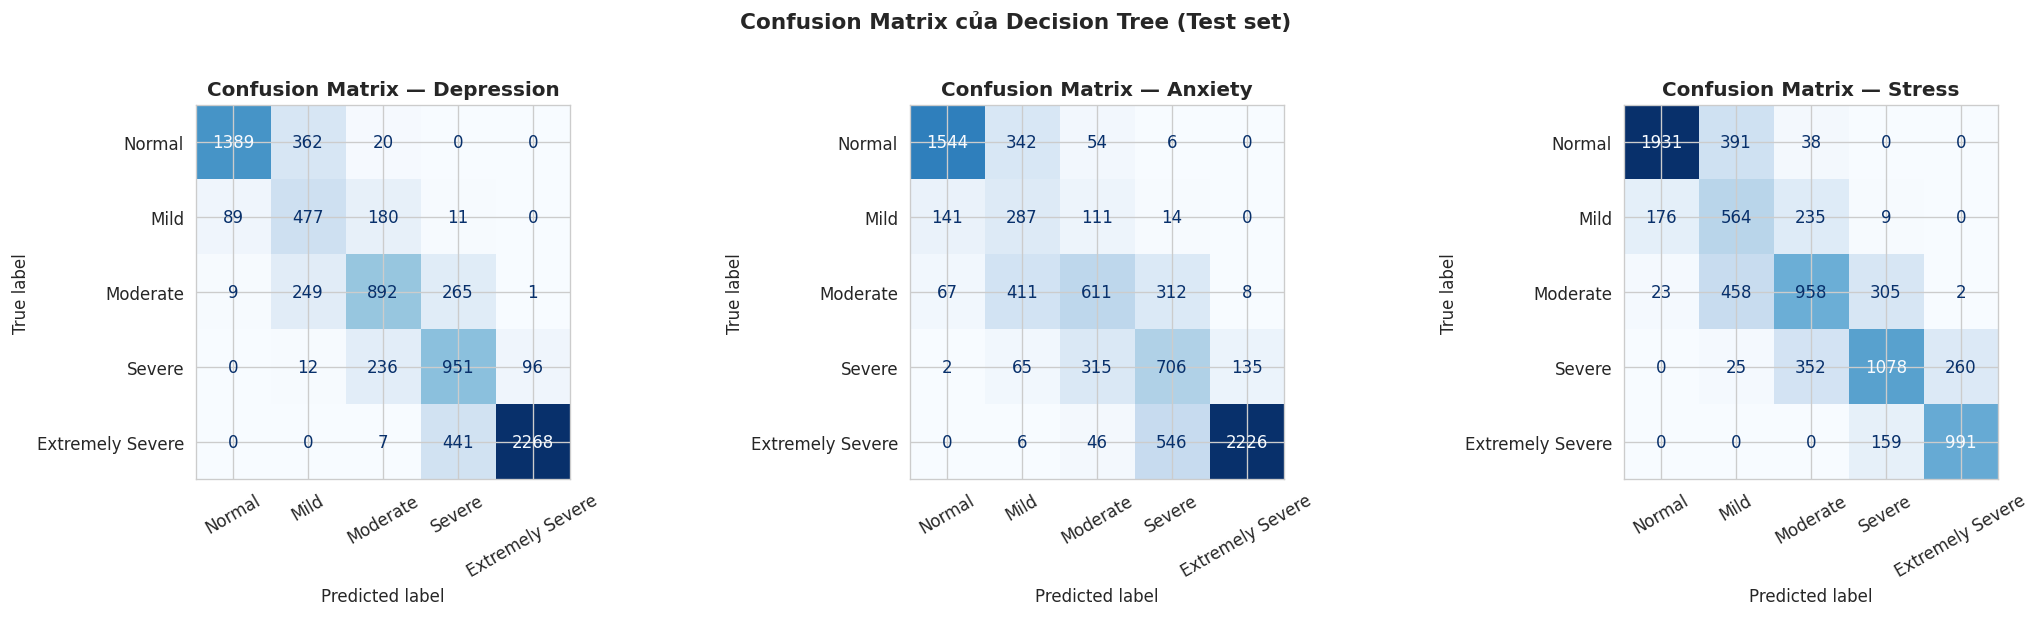

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (group, res) in zip(axes, results.items()):
    y_pred = res['clf'].predict(res['X_test'])
    cm     = confusion_matrix(res['y_test'], y_pred)

    # Chỉ lấy các class thực sự có trong test set
    present = sorted(res['y_test'].unique())
    names   = [LABEL_NAMES[i] for i in present]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {group}', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix của Decision Tree (Test set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**3. Phase 3: Prolog Knowledge Base**

In [ ]:
from pyswip import Prolog

# Lấy câu hỏi sàng lọc từ Decision Tree
screening_map = {}
for group, res in results.items():
    qs = [int(f.replace('Q','').replace('A','')) for f in res['top2'].index]
    screening_map[group] = qs

dep_q1, dep_q2 = screening_map['Depression']
anx_q1, anx_q2 = screening_map['Anxiety']
str_q1, str_q2 = screening_map['Stress']
d_thr = results['Depression']['threshold']
a_thr = results['Anxiety']['threshold']
s_thr = results['Stress']['threshold']

print("📌 Câu hỏi sàng lọc được trích xuất:")
print(f"  Depression : Q{dep_q1}, Q{dep_q2}  (threshold={d_thr})")
print(f"  Anxiety    : Q{anx_q1}, Q{anx_q2}  (threshold={a_thr})")
print(f"  Stress     : Q{str_q1}, Q{str_q2}  (threshold={s_thr})")

📌 Câu hỏi sàng lọc được trích xuất:
  Depression : Q21, Q10  (threshold=1.5)
  Anxiety    : Q28, Q7  (threshold=1.5)
  Stress     : Q11, Q8  (threshold=1.5)


In [ ]:
kb = f"""%%
%% --- Sàng lọc nhanh ---
screening_depression(Q{dep_q1}, Q{dep_q2}, skip_depression, "Rui ro thap: Q{dep_q1} va Q{dep_q2} deu thap") :- Q{dep_q1} =< {d_thr}, Q{dep_q2} =< {d_thr}.
screening_depression(Q{dep_q1}, Q{dep_q2}, ask_more, "Can danh gia them: diem sang loc vuot nguong") :- (Q{dep_q1} > {d_thr} ; Q{dep_q2} > {d_thr}).

screening_anxiety(Q{anx_q1}, Q{anx_q2}, skip_anxiety, "Rui ro thap: Q{anx_q1} va Q{anx_q2} deu thap") :- Q{anx_q1} =< {a_thr}, Q{anx_q2} =< {a_thr}.
screening_anxiety(Q{anx_q1}, Q{anx_q2}, ask_more, "Can danh gia them: diem sang loc vuot nguong") :- (Q{anx_q1} > {a_thr} ; Q{anx_q2} > {a_thr}).

screening_stress(Q{str_q1}, Q{str_q2}, skip_stress, "Rui ro thap: Q{str_q1} va Q{str_q2} deu thap") :- Q{str_q1} =< {s_thr}, Q{str_q2} =< {s_thr}.
screening_stress(Q{str_q1}, Q{str_q2}, ask_more, "Can danh gia them: diem sang loc vuot nguong") :- (Q{str_q1} > {s_thr} ; Q{str_q2} > {s_thr}).

%% --- Tư vấn lời khuyên đơn chiều ---
advice(depression, 0, "Tram cam: Ban dang on dinh. Duy tri loi song lanh manh nhe!").
advice(depression, 1, "Tram cam: Co dau hieu nhe. Tap the duc, ngu du giac va chia se voi nguoi than.").
advice(depression, 2, "Tram cam: Muc do vua. Nen gap chuyen vien tu van de duoc ho tro.").
advice(depression, 3, "Tram cam: Muc do nang. Can tim gap chuyen gia tam ly cang som cang tot.").
advice(depression, 4, "Tram cam: Rat nang. Can can thiep y te khan cap, lien he bac si ngay.").

advice(anxiety, 0, "Lo au: Khong co dau hieu lo au. Rat tot!").
advice(anxiety, 1, "Lo au: Hoi lo au. Thu tap hit tho sau va thien dinh.").
advice(anxiety, 2, "Lo au: Muc do vua. Han che caffeine, nghi ngoi va thu gian.").
advice(anxiety, 3, "Lo au: Nang. Nhung con hoang loan co the xay ra, can su ho tro chuyen gia.").
advice(anxiety, 4, "Lo au: Rat nang. Tim kiem ho tro y te ngay lap tuc.").

advice(stress, 0, "Cang thang: Ban kiem soat cang thang rat tot!").
advice(stress, 1, "Cang thang: Co chut cang thang. Hay thu gian va nghi ngoi.").
advice(stress, 2, "Cang thang: Vua. Can can bang lai cong viec va cuoc song.").
advice(stress, 3, "Cang thang: Nang. Nguy co kiet suc, hay tam dung va gap chuyen gia.").
advice(stress, 4, "Cang thang: Rat nang. Dang qua tai nghiem trong, can can thiep y te.").

%% --- Forward Chaining - Candidata Profile ---

%% Hồ sơ 1: Khủng hoảng toàn diện — D,A,S đều cực nặng (>= 3.8 ~ 38/10)
candidate_profile(maladaptive_crisis, D10, A10, S10) :- D10 >= 30, A10 >= 30, S10 >= 30.

%% Hồ sơ 2: MDD kèm lo âu — D nặng VÀ A nặng (>= 3.0 ~ 30/10)
candidate_profile(mdd_anxious_distress, D10, A10, S10) :- D10 >= 25, A10 >= 25,
                                                      \+ candidate_profile(maladaptive_crisis, D10, A10, S10).

%% Hồ sơ 3: Panic / Lo âu sinh lý cấp tính — A nặng, D thấp, S thấp
candidate_profile(panic_disorder, D10, A10, S10) :- A10 >= 25, D10 =< 15, S10 =< 20,
                                                 \+ candidate_profile(maladaptive_crisis, D10, A10, S10).

%% Hồ sơ 4: GAD / Lo âu lan tỏa mãn tính — S nặng, D thấp, A thấp
candidate_profile(gad_stress_dominant, D10, A10, S10) :- S10 >= 25, D10 =< 15, A10 =< 15,
                                                      \+ candidate_profile(maladaptive_crisis, D10, A10, S10).

%% Hồ sơ 5: Rối loạn thích ứng — S vừa-nặng, D và A không quá cao
candidate_profile(adjustment_disorder, D10, A10, S10) :- S10 >= 18, D10 < 25, A10 < 25,
                                                      \+ candidate_profile(maladaptive_crisis, D10, A10, S10),
                                                      \+ candidate_profile(gad_stress_dominant, D10, A10, S10).

%% Hồ sơ 6: Trầm cảm thuần — D nặng, A và S không cao
candidate_profile(pure_depression, D10, A10, S10) :- D10 >= 25, A10 < 25, S10 < 25,
                                                  \+ candidate_profile(maladaptive_crisis, D10, A10, S10).

%% Fallback: nguy cơ thấp
candidate_profile(low_risk, D10, A10, S10) :- D10 < 15, A10 < 15, S10 < 15.

%% --- Backward Chaining - Xác minh chuẩn đoán ---
ask_symptom(Question) :-
    (   known(Question, yes)  -> true
    ;   known(Question, no)   -> fail
    ;   ask_user(Question)
    ).

ask_user(Question) :-
    format(atom(Prompt), 'ASK:~w', [Question]),
    throw(need_input(Prompt)).

%% --- PURE DEPRESSION ---
verify_diagnosis(pure_depression) :-
    ask_symptom(q_dep_dur),
    ( ask_symptom(q_dep_a1) -> true ; ask_symptom(q_dep_a2) ),
    ask_symptom(q_dep_a3),
    ask_symptom(q_dep_a4),
    ask_symptom(q_dep_a5),
    ask_symptom(q_dep_a6),
    ask_symptom(q_dep_a7),
    ask_symptom(q_dep_a8),
    ask_symptom(q_dep_a9),
    aggregate_all(count,
        ( member(Q, [q_dep_a1, q_dep_a2, q_dep_a3, q_dep_a4,
                     q_dep_a5, q_dep_a6, q_dep_a7, q_dep_a8, q_dep_a9]),
          known(Q, yes) ),
        Count),
    Count >= 5,
    ask_symptom(q_dep_b),
    \+ ask_symptom(q_dep_e).

%% --- GAD ---
verify_diagnosis(gad_stress_dominant) :-
    ask_symptom(q_gad_a),
    ask_symptom(q_gad_b),
    aggregate_all(count,
        ( member(Q, [q_gad_c1, q_gad_c2, q_gad_c3,
                     q_gad_c4, q_gad_c5, q_gad_c6]),
          known(Q, yes) ),
        Count),
    Count >= 3,
    ask_symptom(q_gad_e).

%% --- PANIC DISORDER ---
verify_diagnosis(panic_disorder) :-
    ask_symptom(q_panic_somatic),
    ask_symptom(q_panic_sudden),
    ( ask_symptom(q_panic_worry)
      -> true
      ;  ask_symptom(q_panic_avoid)
    ).

%% --- ADJUSTMENT DISORDER ---
verify_diagnosis(adjustment_disorder) :-
    ask_symptom(q_adj_stressor),
    ask_symptom(q_adj_causal),
    ( ask_symptom(q_adj_disproportionate)
      -> true
      ;  ask_symptom(q_adj_impairment)
    ).

%% --- MDD WITH ANXIOUS DISTRESS ---
verify_diagnosis(mdd_anxious_distress) :-
    aggregate_all(count,
        ( member(Q, [q_mdd_keyed, q_mdd_restless,
                     q_mdd_concentrate, q_mdd_fear]),
          known(Q, yes) ),
        Count),
    Count >= 2.

%% --- AUTO CONFIRM ---
verify_diagnosis(maladaptive_crisis) :- true.
verify_diagnosis(low_risk)           :- true.

%% --- Lời khuyên theo từng nhóm Profile ---
profile_advice(maladaptive_crisis,
    "MỨC ĐỘ NGUY HIỂM: Bạn đang kiệt sức hoàn toàn về mặt tâm lý. Xin đừng cố chịu đựng một mình, hãy liên hệ ngay với bác sĩ tâm lý hoặc đường dây hỗ trợ y tế khẩn cấp để được giúp đỡ.").

profile_advice(mdd_anxious_distress,
    "MỨC ĐỘ NẶNG (Trầm cảm kèm Lo âu): Bạn đang mang một gánh nặng tâm lý rất lớn. Lời khuyên lúc này là tránh để bản thân bị quá tải, hãy bắt đầu từ những hoạt động nhỏ nhất để tìm lại niềm vui, và bạn rất cần một bác sĩ chuyên khoa đồng hành.").

profile_advice(panic_disorder,
    "MỨC ĐỘ NẶNG (Hoảng sợ cấp tính): Cơ thể bạn đang phản ứng thái quá với sự lo âu. Khi cơn hoảng sợ đến, hãy tập hít thở sâu, chạm vào các đồ vật xung quanh để kéo tâm trí về hiện tại. Bạn nên gặp chuyên gia để học cách kiểm soát triệt để triệu chứng này.").

profile_advice(gad_stress_dominant,
    "MỨC ĐỘ VỪA - NẶNG (Lo âu & Căng thẳng kéo dài): Bạn đang bị quá tải và khó ngừng suy nghĩ. Hãy thử các bài tập kéo giãn cơ bắp, dành ra một 'khung giờ lo lắng' cố định thay vì lo âu cả ngày, và trò chuyện với tư vấn viên để giải tỏa.").

profile_advice(adjustment_disorder,
    "MỨC ĐỘ VỪA (Khó khăn thích ứng): Cảm thấy chông chênh sau một biến cố lớn là phản ứng rất bình thường của con người, bạn không có lỗi! Tuy nhiên, để vượt qua giai đoạn này, bạn nên tìm người chia sẻ hoặc tư vấn viên để cùng nhau tháo gỡ từng vấn đề.").

profile_advice(pure_depression,
    "MỨC ĐỘ NẶNG (Trầm cảm): Bạn đang đánh mất năng lượng và niềm vui sống. Hãy cố gắng duy trì một thời gian biểu sinh hoạt cố định, giữ kết nối với những người bạn tin tưởng và đi khám tâm lý để được hỗ trợ phương pháp trị liệu phù hợp.").

profile_advice(low_risk,
    "MỨC ĐỘ AN TOÀN: Không có dấu hiệu nào đáng lo ngại. Sức khỏe tinh thần của bạn hiện tại rất ổn định. Hãy tiếp tục duy trì lối sống lành mạnh, ngủ đủ giấc và vận động thể chất đều đặn nhé.").
"""

with open("knowledge_base.pl", "w", encoding="utf-8") as f:
    f.write(kb)

prolog = Prolog()
prolog.consult("knowledge_base.pl")
print("Knowledge Base đã được nạp vào Prolog!")

Knowledge Base đã được nạp vào Prolog!


**4. Phase 4: Fuzzy Logic Engine**

In [ ]:
# @title
class DASSFuzzySystem:
    def __init__(self):
        self.systems = {
            'depression': self._build('depression', [0,0,9,10],[9,10,13,14],[13,14,20,21],[20,21,27,28],[27,28,42,42]),
            'anxiety':    self._build('anxiety',    [0,0,7,8],[7,8,9,10],[9,10,14,15],[14,15,19,20],[19,20,42,42]),
            'stress':     self._build('stress',     [0,0,14,15],[14,15,18,19],[18,19,25,26],[25,26,33,34],[33,34,42,42]),
        }

    def _build(self, name, norm, mild, mod, sev, ext):
        score = ctrl.Antecedent(np.arange(0, 43, 1), f'{name}_score') # Antecedent (đầu vào) => 0-42
        level = ctrl.Consequent(np.arange(0, 4.1, 0.1), f'{name}_level') # Consequent (đầu ra) => 0-4

        means = {
            #              Normal  Mild   Mod   Sev   ExtSev
            'depression': [ 0,     11,    17,   24,   35],
            'anxiety':    [ 0,      8,    12,   17,   31],
            'stress':     [ 0,     16,    22,   29,   38],
        }
        m = means[name]

        score['normal']           = fuzz.gaussmf(score.universe, m[0], 7)
        score['mild']             = fuzz.gaussmf(score.universe, m[1], 3)
        score['moderate']         = fuzz.gaussmf(score.universe, m[2], 3)
        score['severe']           = fuzz.gaussmf(score.universe, m[3], 3)
        score['extremely_severe'] = fuzz.gaussmf(score.universe, m[4], 7)

        level['normal']           = fuzz.gaussmf(level.universe, 0.0, 0.5)
        level['mild']             = fuzz.gaussmf(level.universe, 1.0, 0.5)
        level['moderate']         = fuzz.gaussmf(level.universe, 2.0, 0.5)
        level['severe']           = fuzz.gaussmf(level.universe, 3.0, 0.5)
        level['extremely_severe'] = fuzz.gaussmf(level.universe, 4.0, 0.5)

        rules = [
            # Rules gốc 1-1
            ctrl.Rule(score['normal'],           level['normal']),
            ctrl.Rule(score['mild'],             level['mild']),
            ctrl.Rule(score['moderate'],         level['moderate']),
            ctrl.Rule(score['severe'],           level['severe']),
            ctrl.Rule(score['extremely_severe'], level['extremely_severe']),

            ctrl.Rule(score['mild']     & score['moderate'], level['moderate']),
            ctrl.Rule(score['moderate'] & score['severe'],   level['severe']),
            ctrl.Rule(score['severe']   & score['extremely_severe'], level['extremely_severe']),
        ]

        sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
        return {'sim': sim, 'score_var': score, 'level_var': level}

    def evaluate(self, name, score_val):
        sim = self.systems[name]['sim']
        sim.input[f'{name}_score'] = score_val
        sim.compute()
        crisp = sim.output[f'{name}_level']

        if   crisp < 0.5: label_idx = 0
        elif crisp < 1.5: label_idx = 1
        elif crisp < 2.5: label_idx = 2
        elif crisp < 3.5: label_idx = 3
        else:             label_idx = 4

        return {
            'score': score_val,
            'fuzzy_value': round(crisp, 3),
            'label_idx': label_idx,
            'label': LABEL_NAMES[label_idx],
        }

fuzzy_doctor = DASSFuzzySystem()

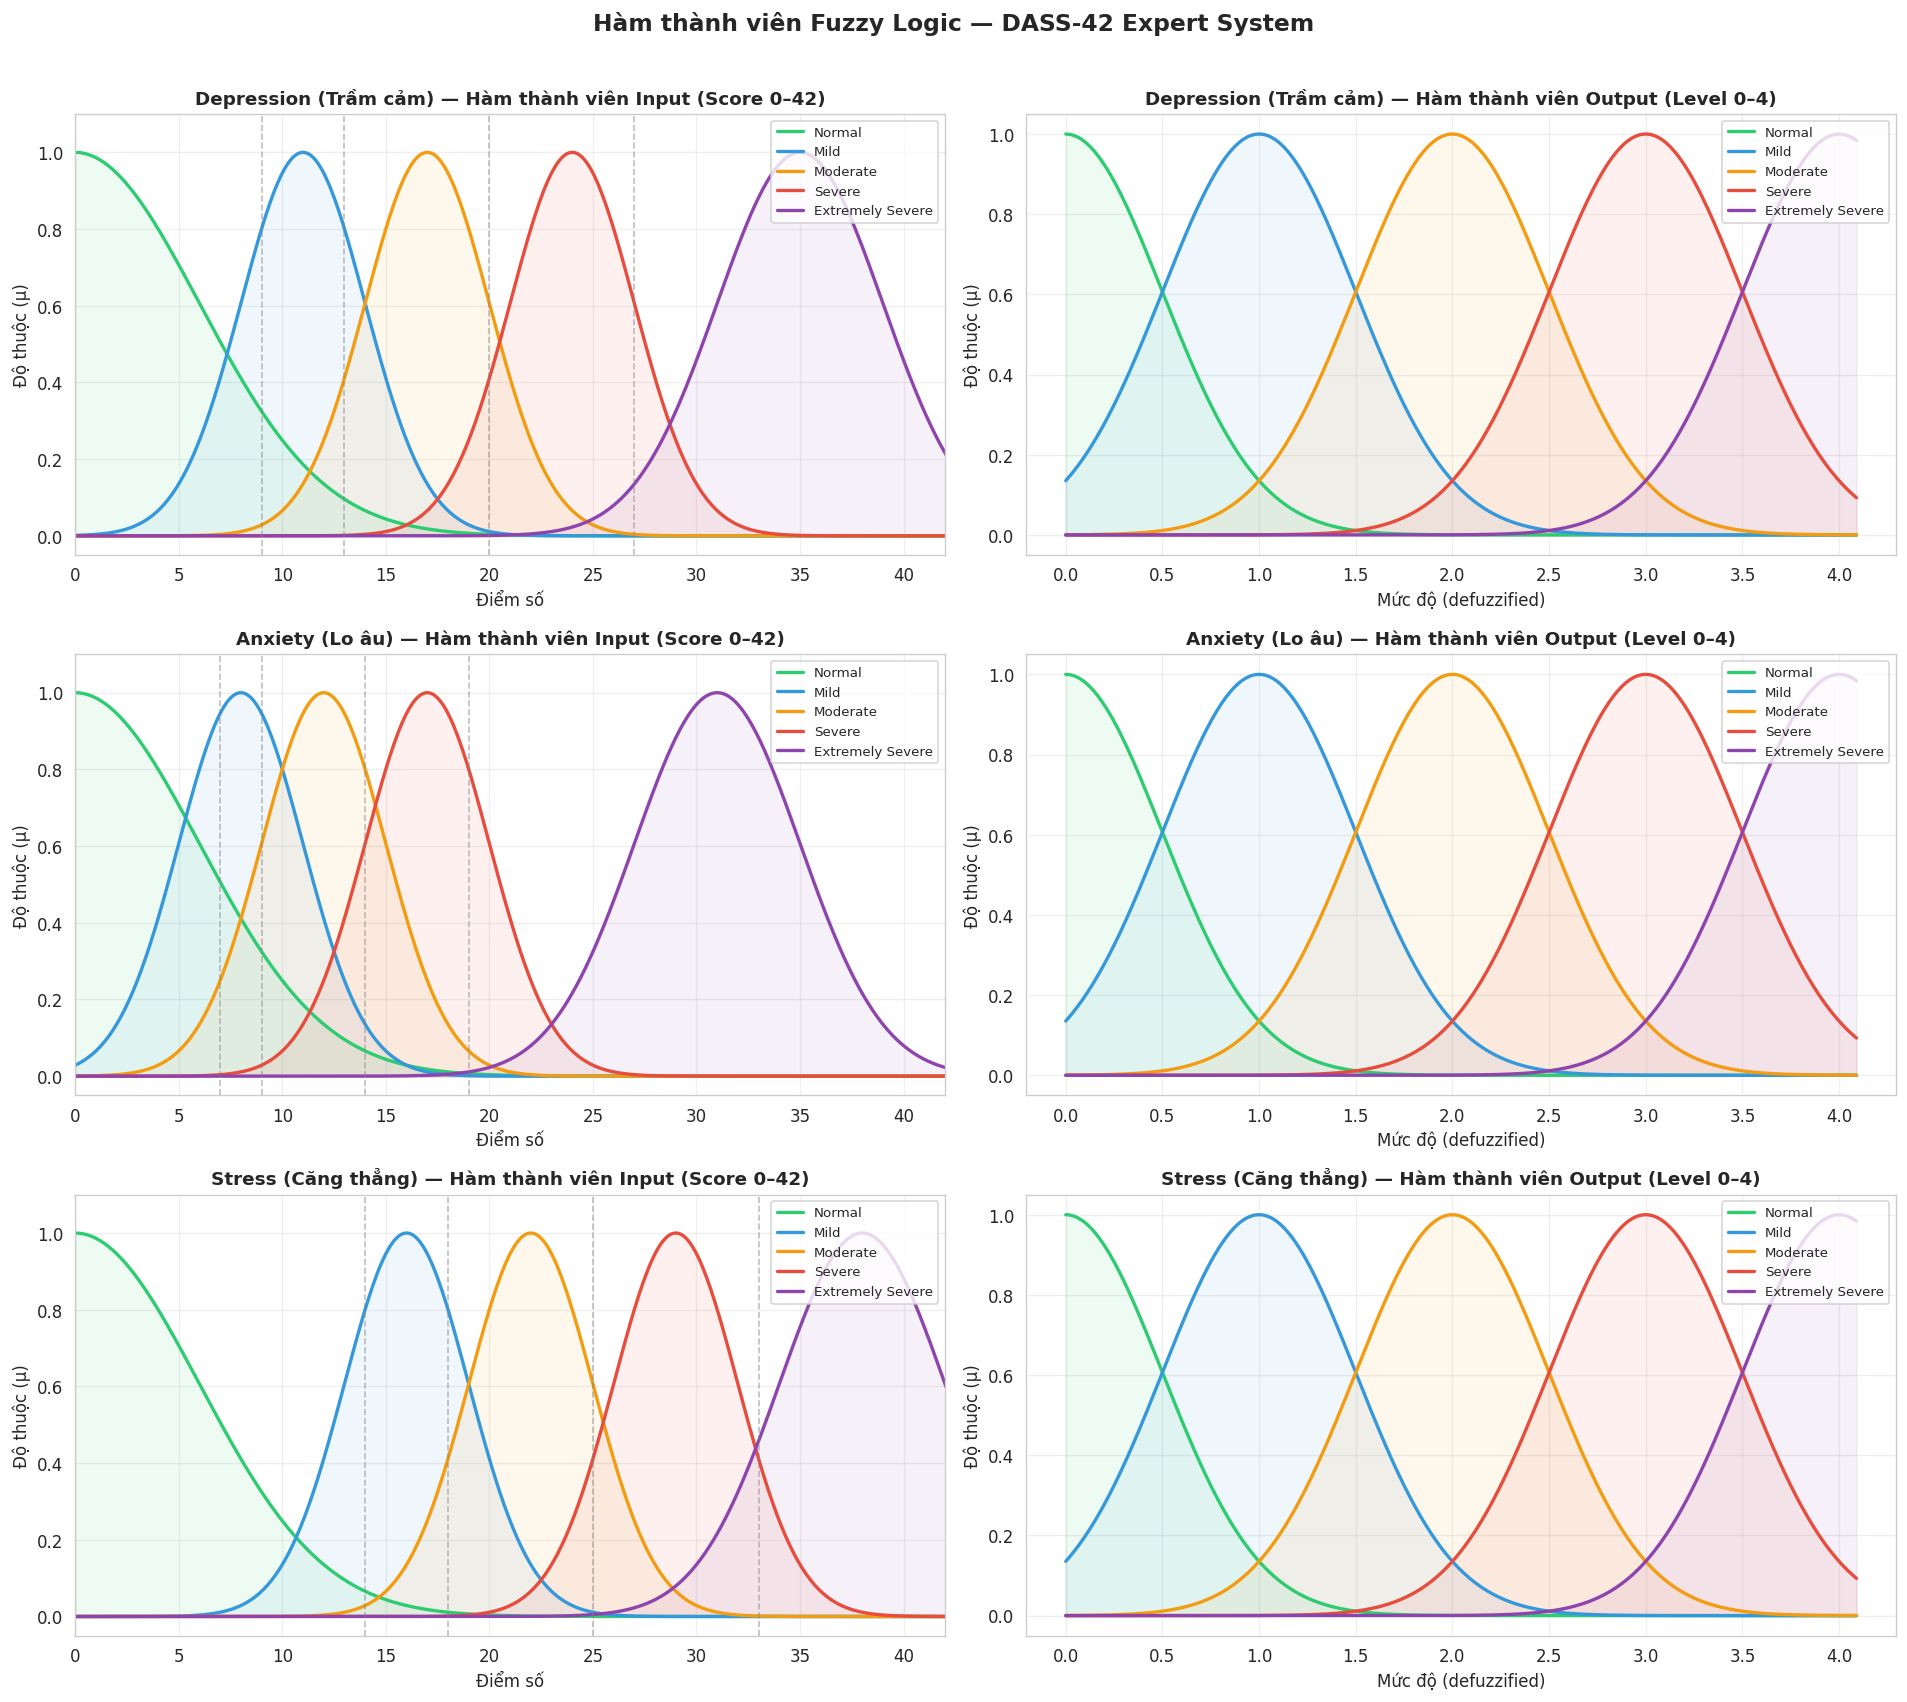

In [ ]:
# @title
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

configs = [
    ('depression', [0,0,9,10],[9,10,13,14],[13,14,20,21],[20,21,27,28],[27,28,42,42],
     '#e74c3c', 'Depression (Trầm cảm)'),
    ('anxiety',   [0,0,7,8],[7,8,9,10],[9,10,14,15],[14,15,19,20],[19,20,42,42],
     '#e67e22', 'Anxiety (Lo âu)'),
    ('stress',    [0,0,14,15],[14,15,18,19],[18,19,25,26],[25,26,33,34],[33,34,42,42],
     '#3498db', 'Stress (Căng thẳng)'),
]

x = np.arange(0, 43, 0.1)

for row, (name, norm, mild, mod, sev, ext, color, title) in enumerate(configs):
    ax_input  = axes[row][0]
    ax_output = axes[row][1]

    # ---- Input: Membership functions ----
    gauss_params = {
        'depression': [(0,6),(11,3),(17,3),(24,3),(35,4)],
        'anxiety':    [(0,6),( 8,3),(12,3),(17,3),(31,4)],
        'stress':     [(0,6),(16,3),(22,3),(29,3),(38,4)],
    }
    colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#8e44ad']
    labels = ['Normal','Mild','Moderate','Severe','Extremely Severe']

    params = gauss_params[name]
    mfs = [
        (labels[i], fuzz.gaussmf(x, params[i][0], params[i][1]), colors[i])
        for i in range(5)
    ]
    for label, mf, c in mfs:
        ax_input.plot(x, mf, label=label, color=c, linewidth=2)
        ax_input.fill_between(x, mf, alpha=0.08, color=c)

    ax_input.set_title(f'{title} — Hàm thành viên Input (Score 0–42)',
                       fontweight='bold', fontsize=11)
    ax_input.set_xlabel('Điểm số')
    ax_input.set_ylabel('Độ thuộc (μ)')
    ax_input.legend(loc='upper right', fontsize=8)
    ax_input.set_xlim(0, 42)
    ax_input.set_ylim(-0.05, 1.1)
    ax_input.grid(alpha=0.3)

    # Thêm đường ngưỡng phân loại chuẩn DASS
    thresholds = {
        'depression': [9, 13, 20, 27],
        'anxiety':    [7, 9, 14, 19],
        'stress':     [14, 18, 25, 33],
    }
    for thr in thresholds[name]:
        ax_input.axvline(thr, color='gray', linestyle='--', alpha=0.5, linewidth=1)

    # ---- Output: Membership functions (level 0–4) ----
    y_out = np.arange(0, 4.1, 0.01)
    out_mfs = [
        (labels[i], fuzz.gaussmf(y_out, float(i), 0.5), colors[i])
        for i in range(5)
    ]
    for label, mf, c in out_mfs:
        ax_output.plot(y_out, mf, label=label, color=c, linewidth=2)
        ax_output.fill_between(y_out, mf, alpha=0.08, color=c)

    ax_output.set_title(f'{title} — Hàm thành viên Output (Level 0–4)',
                        fontweight='bold', fontsize=11)
    ax_output.set_xlabel('Mức độ (defuzzified)')
    ax_output.set_ylabel('Độ thuộc (μ)')
    ax_output.legend(loc='upper right', fontsize=8)
    ax_output.grid(alpha=0.3)

plt.suptitle('Hàm thành viên Fuzzy Logic — DASS-42 Expert System',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

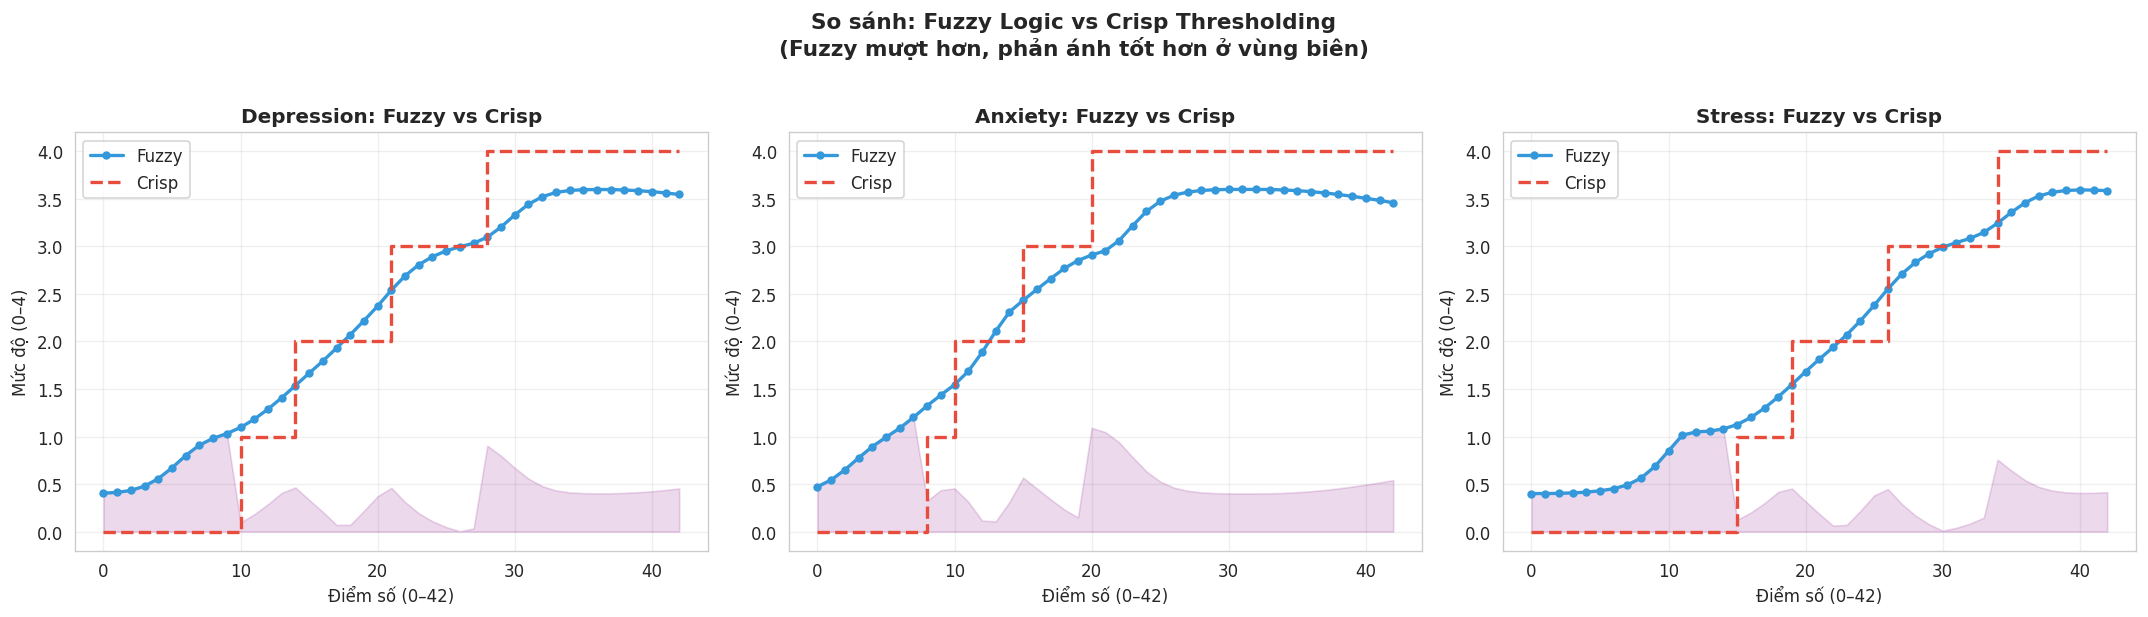

In [ ]:
# @title
sample_scores = np.arange(0, 43, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, label_fn, title) in zip(axes, [
    ('depression', label_depression, 'Depression'),
    ('anxiety',    label_anxiety,    'Anxiety'),
    ('stress',     label_stress,     'Stress'),
]):
    fuzzy_vals = [fuzzy_doctor.evaluate(name, s)['fuzzy_value'] for s in sample_scores]
    crisp_vals = [label_fn(s) for s in sample_scores]

    ax.plot(sample_scores, fuzzy_vals, 'o-', color='#3498db',
            label='Fuzzy', linewidth=2, markersize=4)
    ax.step(sample_scores, crisp_vals, where='post', color='#e74c3c',
            label='Crisp', linewidth=2, linestyle='--')

    ax.set_title(f'{title}: Fuzzy vs Crisp', fontweight='bold')
    ax.set_xlabel('Điểm số (0–42)')
    ax.set_ylabel('Mức độ (0–4)')
    ax.legend()
    ax.grid(alpha=0.3)
    # Tô vùng biên
    ax.fill_between(sample_scores,
                    [abs(f-c) for f,c in zip(fuzzy_vals,crisp_vals)],
                    alpha=0.15, color='purple', label='Vùng khác biệt')

plt.suptitle('So sánh: Fuzzy Logic vs Crisp Thresholding\n'
             '(Fuzzy mượt hơn, phản ánh tốt hơn ở vùng biên)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**5. Phase 5: Tích hợp hệ chuyên gia**

**Pipeline:** Input → Prolog Screening → Fuzzy → Advice

In [ ]:
# @title
def run_expert_system(answers: dict, verbose=True) -> dict:
    """
    answers: dict {Q_num: score(0-3)}
    Trả về kết quả chẩn đoán với quy trình tính toán CHI TIẾT (Debug Log mode).
    """
    def clean(val):
        return val.decode('utf-8') if isinstance(val, bytes) else str(val)

    def get_score(q_num):
        return answers.get(q_num, 0)

    def line(char='-', n=70):
        return char * n

    def get_memberships(name, score_val):
        sys_data = fuzzy_doctor.systems[name]
        score_var = sys_data['score_var']
        memberships = {}
        for term_name, term_obj in score_var.terms.items():
            memberships[term_name] = float(fuzz.interp_membership(
                score_var.universe, term_obj.mf, score_val))
        return memberships

    def get_gauss_params(name):
        sys_data  = fuzzy_doctor.systems[name]
        score_var = sys_data['score_var']
        universe  = score_var.universe
        params = {}
        for term_name, term_obj in score_var.terms.items():
            mf_array = term_obj.mf
            mean_idx = np.argmax(mf_array)
            mean     = universe[mean_idx]
            candidates = [(i, x, mu) for i, (x, mu) in enumerate(zip(universe, mf_array))
                          if 0.01 < mu < 0.99 and x != mean]
            if candidates:
                _, x_c, mu_c = min(candidates, key=lambda v: abs(v[2] - 0.5))
                sigma = round(float(np.sqrt(-(x_c - mean)**2 / (2 * np.log(mu_c)))), 1)
            else:
                sigma = 1.0
            params[term_name] = {'mean': int(mean), 'sigma': sigma}
        return params

    final_results = {}

    if verbose:
        print(line('='))
        print(f"{'HỆ CHUYÊN GIA ĐÁNH GIÁ SỨC KHỎE TÂM THẦN — DASS-42':^70}")
        print(line('='))

    screening_configs = [
        ('depression', dep_q1, dep_q2, 'screening_depression', DEPRESSION_Qs),
        ('anxiety',    anx_q1, anx_q2, 'screening_anxiety',    ANXIETY_Qs),
        ('stress',     str_q1, str_q2, 'screening_stress',     STRESS_Qs),
    ]

    dim_labels = {
        'depression': 'TRẦM CẢM (Depression)',
        'anxiety':    'LO ÂU (Anxiety)',
        'stress':     'CĂNG THẲNG (Stress)',
    }

    term_order  = ['normal', 'mild', 'moderate', 'severe', 'extremely_severe']
    term_labels = {'normal': 'Normal', 'mild': 'Mild', 'moderate': 'Moderate',
                   'severe': 'Severe', 'extremely_severe': 'Ext. Severe'}

    for dim, q1, q2, pred, all_qs in screening_configs:
        s1, s2 = get_score(q1), get_score(q2)
        res    = list(prolog.query(f"{pred}({s1},{s2},Action,Reason)"))[0]
        action = clean(res['Action'])
        reason = clean(res['Reason'])

        if verbose:
            print(f"\n[{dim_labels[dim]}]")
            print(line('-'))

            # --- BƯỚC 1: Sàng lọc ---
            print(f" BƯỚC 1: SÀNG LỌC NHANH (Prolog Screening)")
            print(f"   - Đầu vào             : Q{q1} = {s1}  |  Q{q2} = {s2}")
            # Lấy threshold từ dictionary results ở Phase 2
            threshold = results[dim.capitalize()]['threshold']
            print(f"   - Ngưỡng sàng lọc     : ≤ {threshold}")
            print(f"   - Hành động (Action)  : {action.upper()}")
            print(f"   - Lý do Prolog        : {reason}\n")

        if action.startswith('skip'):
            if verbose:
                print(f"   => Bỏ qua chiều này — rủi ro thấp.\n")
            final_results[dim] = {
                'screening_action': action,
                'total_score': 0,
                'fuzzy_value': 0.0,
                'label': 'Normal',
                'label_idx': 0,
                'advice': 'Không cần đánh giá thêm.',
            }
            continue

        # --- BƯỚC 2: Tính điểm ---
        if action == 'ask_more':
            total      = sum(get_score(q) for q in all_qs)
            score_src  = 'Tổng điểm 14 câu đầy đủ'
            detail_scores = [get_score(q) for q in all_qs]
        else:
            total      = round((s1 + s2) / 2 * 14)
            score_src  = f'Nội suy từ 2 câu: ({s1}+{s2})/2 × 14'
            detail_scores = None

        if verbose:
            print(f" BƯỚC 2: TÍNH ĐIỂM TỔNG")
            print(f"   - Phương pháp         : {score_src}")
            if detail_scores:
                print(f"   - Chi tiết từng câu   : ", end='')
                items = [f"Q{q}={v}" for q, v in zip(all_qs, detail_scores)]
                for k, item in enumerate(items):
                    if k > 0 and k % 7 == 0:
                        print(f"\n                           ", end='')
                    print(f"{item:<8}", end='')
                print()
            print(f"   → ĐIỂM TỔNG           : {total} / 42\n")

        # --- BƯỚC 3: Fuzzification ---
        memberships = get_memberships(dim, total)
        gauss_params = get_gauss_params(dim)

        if verbose:
            print(f" BƯỚC 3: MỜ HÓA (FUZZIFICATION)")
            print(f"   {'Tập mờ':<15} | {'Công thức':^42} | μ")
            print(f"   {line('.', 65)}")
            for t in term_order:
                mu    = memberships.get(t, 0.0)
                mean  = gauss_params[t]['mean']
                sigma = gauss_params[t]['sigma']
                formula = f"exp(-(({total}-{mean:>2})² / (2×{sigma}²)))"
                flag  = ' ◄' if mu > 0.001 else ''
                print(f"   {term_labels[t]:<15} | {formula:<42} | {mu:.3f}{flag}")
            print()

        # --- BƯỚC 4: Rule activation + Defuzzification ---
        fuzzy_res    = fuzzy_doctor.evaluate(dim, total)
        crisp_val    = fuzzy_res['fuzzy_value']
        label_idx    = fuzzy_res['label_idx']
        active_rules = [(t, memberships.get(t, 0.0)) for t in term_order if memberships.get(t, 0.0) > 0.001]

        # Lấy center của output level (0,1,2,3,4)
        level_centers = {'normal': 0, 'mild': 1, 'moderate': 2, 'severe': 3, 'extremely_severe': 4}

        if verbose:
            print(f" BƯỚC 4: SUY DIỄN & GIẢI MỜ (DEFUZZIFICATION - Centroid)")

            # Tử số — từng hạng tử
            numerator_terms   = [(t, memberships.get(t,0.0), level_centers[t]) for t in term_order]
            numerator_parts   = [f"({mu:.3f}×{c})" for t, mu, c in numerator_terms]
            numerator_vals    = [mu * c               for t, mu, c in numerator_terms]
            denominator_terms = [mu                   for t, mu, c in numerator_terms]

            numerator_sum   = sum(numerator_vals)
            denominator_sum = sum(denominator_terms)

            print(f"   Tử số  = {' + '.join(numerator_parts)}")
            print(f"          = {' + '.join(f'{v:.3f}' for v in numerator_vals)}")
            print(f"          = {numerator_sum:.3f}")
            print(f"   Mẫu số = {' + '.join(f'{mu:.3f}' for _,mu,_ in numerator_terms)}")
            print(f"          = {denominator_sum:.3f}")
            print(f"   → CRISP = {numerator_sum:.3f} / {denominator_sum:.3f} = {crisp_val:.4f} (Thang 0-4)")
            print()

        # --- BƯỚC 5: Lời khuyên đơn nhóm ---
        adv_res = list(prolog.query(f"advice({dim},{label_idx},Advice)"))[0]
        advice  = clean(adv_res['Advice'])

        if verbose:
            print(f" BƯỚC 5: KẾT LUẬN & LỜI KHUYÊN")
            print(f"   - Mức độ chẩn đoán    : {LABEL_NAMES[label_idx].upper()}")
            print(f"   - Thông điệp y khoa   : {advice}\n")

        final_results[dim] = {
            'screening_action': action,
            'total_score': total,
            'fuzzy_value': crisp_val,
            'label': LABEL_NAMES[label_idx],
            'label_idx': label_idx,
            'advice': advice,
        }

    d_fv = final_results['depression']['fuzzy_value']
    a_fv = final_results['anxiety']['fuzzy_value']
    s_fv = final_results['stress']['fuzzy_value']

    d10 = round(d_fv * 10)
    a10 = round(a_fv * 10)
    s10 = round(s_fv * 10)

    # ---  BƯỚC 6: Forward Chaining — Nhận diện candidate profile ---
    candidate_res = list(prolog.query(f"candidate_profile(Profile, {d10}, {a10}, {s10})"))
    profile = clean(candidate_res[0]['Profile']) if candidate_res else 'low_risk'

    # --- BƯỚC 7: Backward Chaining — hỏi xác nhận (nếu cần) ---
    symptom_questions = {
        'pure_depression': {
            'q_dep_dur': "Các triệu chứng này có xuất hiện liên tục trong cùng khoảng 2 tuần không?",
            'q_dep_a1':  "Bạn có cảm thấy buồn, trống rỗng hoặc tuyệt vọng gần như cả ngày, mỗi ngày không?",
            'q_dep_a2':  "Bạn có mất hứng thú hoặc niềm vui với hầu hết hoạt động từng yêu thích không?",
            'q_dep_a3':  "Bạn có thay đổi cân nặng rõ rệt (>5%) hoặc thay đổi cảm giác thèm ăn không?",
            'q_dep_a4':  "Bạn có bị mất ngủ hoặc ngủ quá nhiều gần như mỗi ngày không?",
            'q_dep_a5':  "Người xung quanh có nhận thấy bạn chậm chạp hoặc bồn chồn bất thường không?",
            'q_dep_a6':  "Bạn có cảm thấy mệt mỏi hoặc mất năng lượng gần như mỗi ngày không?",
            'q_dep_a7':  "Bạn có thường cảm thấy bản thân vô giá trị hoặc tội lỗi quá mức không?",
            'q_dep_a8':  "Bạn có khó tập trung, suy nghĩ hoặc đưa ra quyết định không?",
            'q_dep_a9':  "Bạn có suy nghĩ lặp lại về cái chết hoặc tự làm hại bản thân không?",
            'q_dep_b':   "Các triệu chứng này có ảnh hưởng rõ đến công việc, học tập hoặc các mối quan hệ không?",
            'q_dep_e':   "Bạn có từng trải qua giai đoạn ngược lại — cực kỳ hưng phấn, tràn đầy năng lượng bất thường kéo dài vài ngày không?",
        },
        'gad_stress_dominant': {
            'q_gad_duration': "Bạn có lo lắng thái quá về nhiều vấn đề khác nhau liên tục trong hơn 6 tháng qua không?",
            'q_gad_control':  "Bạn có cảm thấy khó hoặc không thể ngừng lo lắng dù bản thân muốn không?",
            'q_gad_somatic':  "Sự lo âu có đi kèm căng cơ, mệt mỏi, khó tập trung hoặc mất ngủ không?",
        },
        'panic_disorder': {
            'q_panic_somatic': "Bạn có từng đột ngột bị tim đập mạnh, khó thở, vã mồ hôi hoặc run rẩy không rõ nguyên nhân không?",
            'q_panic_sudden':  "Những cơn đó có ập đến bất ngờ và đạt đỉnh điểm chỉ trong vài phút không?",
            'q_panic_worry':   "Sau các cơn đó, bạn có lo lắng kéo dài rằng chúng sẽ tái phát không?",
            'q_panic_avoid':   "Bạn có né tránh những nơi hoặc tình huống cụ thể vì sợ cơn hoảng loạn tái phát không?",
        },
        'adjustment_disorder': {
            'q_adj_stressor':        "Bạn có trải qua biến cố lớn trong 3 tháng qua không? (mất việc, chia tay, chuyển nơi ở...)",
            'q_adj_causal':          "Những căng thẳng hiện tại có bùng phát rõ ràng từ sau biến cố đó không?",
            'q_adj_disproportionate':"Cảm xúc của bạn có vượt quá mức bình thường so với sự kiện đó không?",
            'q_adj_impairment':      "Nó có ảnh hưởng rõ đến công việc, học tập hoặc các mối quan hệ không?",
        },
        'mdd_anxious_distress': {
            'q_mdd_keyed':       "Bạn có thường xuyên cảm thấy bồn chồn, căng thẳng như đang bị kéo căng không?",
            'q_mdd_restless':    "Bạn có bứt rứt đến mức không thể ngồi yên một chỗ không?",
            'q_mdd_concentrate': "Sự lo lắng có khiến bạn mất khả năng tập trung vào công việc/học tập không?",
            'q_mdd_fear':        "Bạn có liên tục sợ hãi rằng một điều tồi tệ sắp xảy ra không?",
        },
    }

    confirm_score = 0
    confirm_detail = []

    if profile in symptom_questions:
        qs = symptom_questions[profile]

        if verbose:
            print(f"\n BƯỚC 7 — BACKWARD CHAINING")
            print(f"   Profile nghi ngờ: {profile.upper()}\n")

        while True:
            try:
                verify_res = list(prolog.query(f"verify_diagnosis({profile})"))
                verified = len(verify_res) > 0
                break
            except Exception as e:
                err = str(e)
                if 'need_input' not in err:
                    verified = False
                    break

                # ✅ Fix 1: Parse q_key bằng regex, không dùng split/rstrip
                match = re.search(r'ASK:(\w+)', err)
                if not match:
                    verified = False
                    break
                q_key = match.group(1)
                q_text = qs.get(q_key, q_key)

                while True:
                    user_ans = input(f"  → {q_text} (yes/no): ").strip().lower()
                    if user_ans in ('yes', 'no'):
                        break
                    print("     Chỉ nhập 'yes' hoặc 'no'.")

                # ✅ Fix 2: Quote atom đúng cách
                prolog.assertz(f"known({q_key}, '{user_ans}')")
                if user_ans == 'yes':
                    confirm_score += 1
                confirm_detail.append((q_text, user_ans))
    else:
        verified = True

    if profile in symptom_questions and not verified:
        profile = 'low_risk'

    adv_res     = list(prolog.query(f"profile_advice({profile}, Advice)"))
    profile_adv = clean(adv_res[0]['Advice']) if adv_res else "Vui long tham khao chuyen gia."

    try:
        list(prolog.query("retractall(known(_,_))"))
    except Exception:
        pass

    if verbose:
        print(line('='))
        print(f"{'TỔNG KẾT KẾT QUẢ ĐÁNH GIÁ ĐA CHIỀU':^70}")
        print(line('='))
        print(f" {'Chiều tâm lý':<22} | {'Điểm':^6} | {'Fuzzy':^7} | {'Kết luận'}")
        print(line('-', 70))
        for dim, r in final_results.items():
            print(f" {dim_labels[dim]:<22} | {r['total_score']:>3}/42  | {r['fuzzy_value']:.3f}   | {r['label'].upper()}")

        print(f"\n {'─'*68}")
        print(f" BƯỚC 6 — FORWARD CHAINING (nhận diện hồ sơ bệnh lý)")
        print(f"   Fuzzy input (×10) : D={d10}  A={a10}  S={s10}")
        print(f"   → Hồ sơ nhận diện : {profile.upper()}")

        if confirm_detail:
            print(f"\n BƯỚC 7 — BACKWARD CHAINING (xác minh lâm sàng)")
            for i, (q_text, ans) in enumerate(confirm_detail, 1):
                mark = "✓" if ans == 'yes' else "✗"
                print(f"   [{mark}] Q{i}: {q_text}")
            total_asked = len(confirm_detail)
            print(f"   → Xác nhận        : {'ĐÃ XÁC NHẬN' if verified else 'CHƯA ĐỦ TIÊU CHÍ'} ({confirm_score}/{total_asked} triệu chứng)")

        print(f"\n [KẾT LUẬN CHẨN ĐOÁN — {profile.upper()}]")
        print(f"   {profile_adv}")
        print(line('='))

    final_results['profile']       = profile
    final_results['profile_verified'] = verified
    final_results['profile_advice']   = profile_adv
    return final_results

In [ ]:
case_dep = {
    "name": "Case: Pure Depression",
    "desc": "Trầm cảm nặng, lo âu và stress thấp → kích hoạt backward chaining",
    "answers": {
        **{q: 0 for q in range(1, 43)},
        **{q: 3 for q in DEPRESSION_Qs},   # D cực nặng
        **{q: 1 for q in ANXIETY_Qs},      # A thấp
        **{q: 1 for q in STRESS_Qs},       # S thấp
    },
}
print(f"\n{'='*70}")
print(f"   {case_dep['name']}")
print(f"   {case_dep['desc']}")
print(f"{'='*70}")
run_expert_system(case_dep['answers'], verbose=True)


   Case: Pure Depression
   Trầm cảm nặng, lo âu và stress thấp → kích hoạt backward chaining
          HỆ CHUYÊN GIA ĐÁNH GIÁ SỨC KHỎE TÂM THẦN — DASS-42          

[TRẦM CẢM (Depression)]
----------------------------------------------------------------------
 BƯỚC 1: SÀNG LỌC NHANH (Prolog Screening)
   - Đầu vào             : Q21 = 3  |  Q10 = 3
   - Ngưỡng sàng lọc     : ≤ 1.5
   - Hành động (Action)  : ASK_MORE
   - Lý do Prolog        : Can danh gia them: diem sang loc vuot nguong

 BƯỚC 2: TÍNH ĐIỂM TỔNG
   - Phương pháp         : Tổng điểm 14 câu đầy đủ
   - Chi tiết từng câu   : Q3=3    Q5=3    Q10=3   Q13=3   Q16=3   Q17=3   Q21=3   
                           Q24=3   Q26=3   Q31=3   Q34=3   Q37=3   Q38=3   Q42=3   
   → ĐIỂM TỔNG           : 42 / 42

 BƯỚC 3: MỜ HÓA (FUZZIFICATION)
   Tập mờ          |                 Công thức                  | μ
   .................................................................
   Normal          | exp(-((42- 0)² / (2×7.0²)))          

{'depression': {'screening_action': 'ask_more',
  'total_score': 42,
  'fuzzy_value': np.float64(3.546),
  'label': 'Extremely Severe',
  'label_idx': 4,
  'advice': 'Tram cam: Rat nang. Can can thiep y te khan cap, lien he bac si ngay.'},
 'anxiety': {'screening_action': 'skip_anxiety',
  'total_score': 0,
  'fuzzy_value': 0.0,
  'label': 'Normal',
  'label_idx': 0,
  'advice': 'Không cần đánh giá thêm.'},
 'stress': {'screening_action': 'skip_stress',
  'total_score': 0,
  'fuzzy_value': 0.0,
  'label': 'Normal',
  'label_idx': 0,
  'advice': 'Không cần đánh giá thêm.'},
 'profile': 'low_risk',
 'profile_verified': False,
 'profile_advice': 'MỨC ĐỘ AN TOÀN: Không có dấu hiệu nào đáng lo ngại. Sức khỏe tinh thần của bạn hiện tại rất ổn định. Hãy tiếp tục duy trì lối sống lành mạnh, ngủ đủ giấc và vận động thể chất đều đặn nhé.'}